# Week 4 - Final Machine Learning Project

# Employee Attrition Prediction using Machine Learning

## Dataset

**Dataset Name:** IBM HR Analytics Employee Attrition & Performance

**Source:** Kaggle Dataset

## Problem Statement

The goal of this project is to build a machine learning model that predicts whether an employee is likely to leave the company (Attrition = Yes or No) based on employee information such as age, job role, monthly income, work experience, overtime, and other workplace-related factors.

## Why is this problem important?

Employee attrition is an important challenge for many organizations because losing experienced employees can increase recruitment costs and affect productivity. By predicting which employees are more likely to leave, companies can take preventive actions to improve employee satisfaction and retention. This project also provides a practical example of applying machine learning techniques to solve a real-world business problem.

## Objective

The objective of this project is to perform data exploration, preprocess the dataset, train multiple machine learning models, compare their performance, tune the best-performing model, and evaluate its ability to predict employee attrition accurately.

In [42]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [43]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [44]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [45]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1470, 35)


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [47]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [48]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [49]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the dataset by identifying patterns, distributions, and relationships between different features. It also helps us gain insights into employee attrition before building machine learning models.

In [50]:
# Attrition distribution

df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

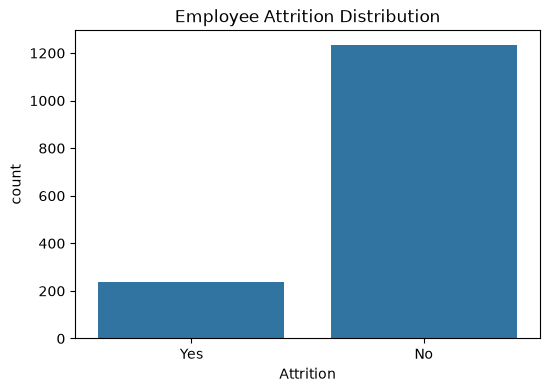

In [51]:
plt.figure(figsize=(6,4))

sns.countplot(x="Attrition", data=df)

plt.title("Employee Attrition Distribution")

plt.show()

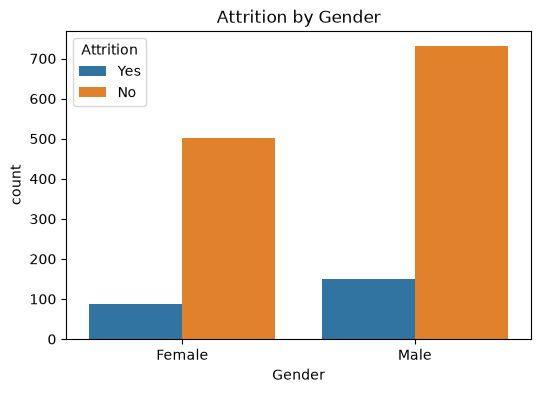

In [52]:
plt.figure(figsize=(6,4))

sns.countplot(x="Gender", hue="Attrition", data=df)

plt.title("Attrition by Gender")

plt.show()

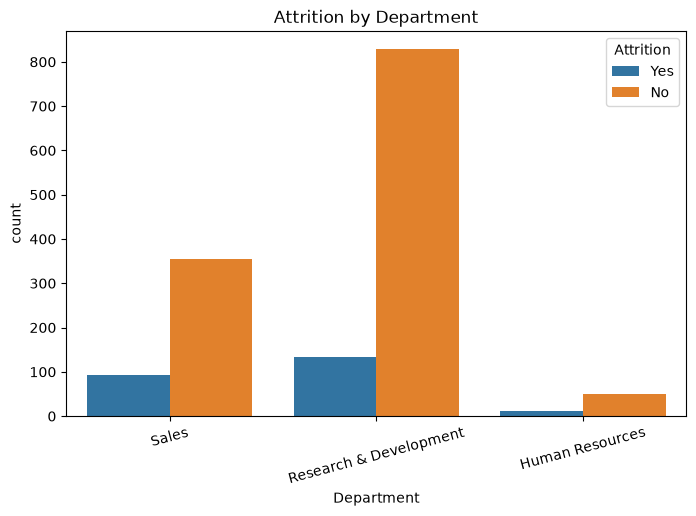

In [53]:
plt.figure(figsize=(8,5))

sns.countplot(x="Department", hue="Attrition", data=df)

plt.title("Attrition by Department")

plt.xticks(rotation=15)

plt.show()

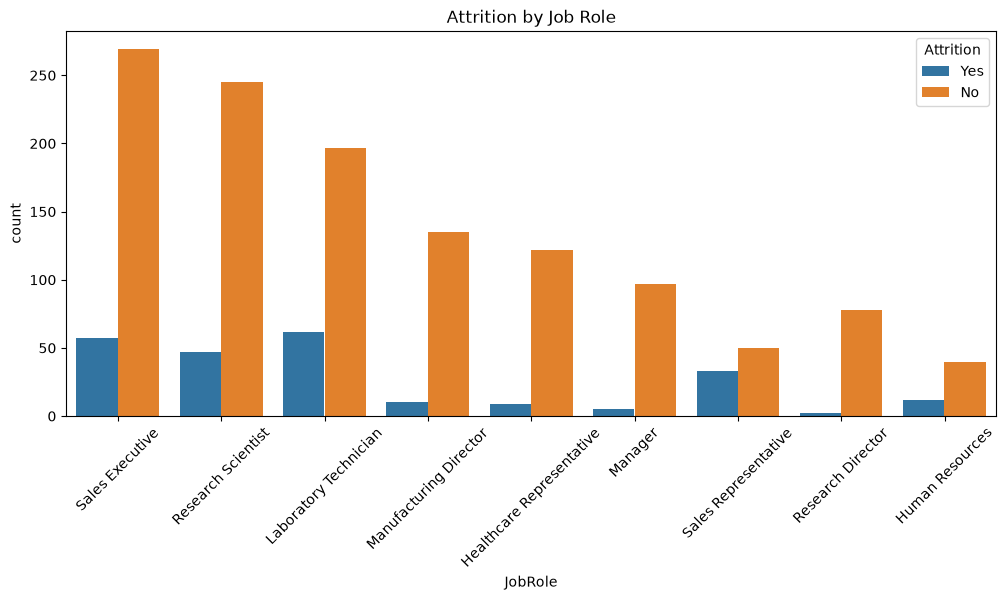

In [54]:
plt.figure(figsize=(12,5))

sns.countplot(x="JobRole", hue="Attrition", data=df)

plt.title("Attrition by Job Role")

plt.xticks(rotation=45)

plt.show()

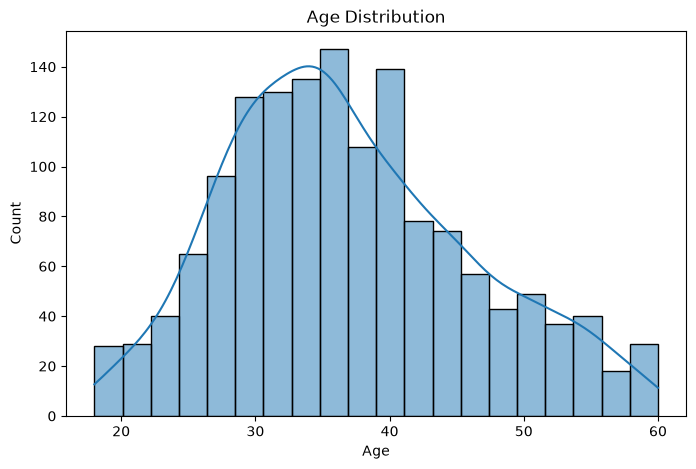

In [55]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")

plt.show()

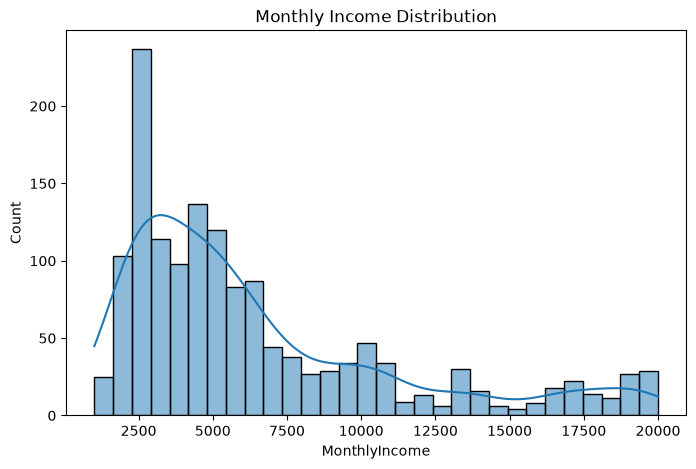

In [56]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyIncome"], bins=30, kde=True)

plt.title("Monthly Income Distribution")

plt.show()

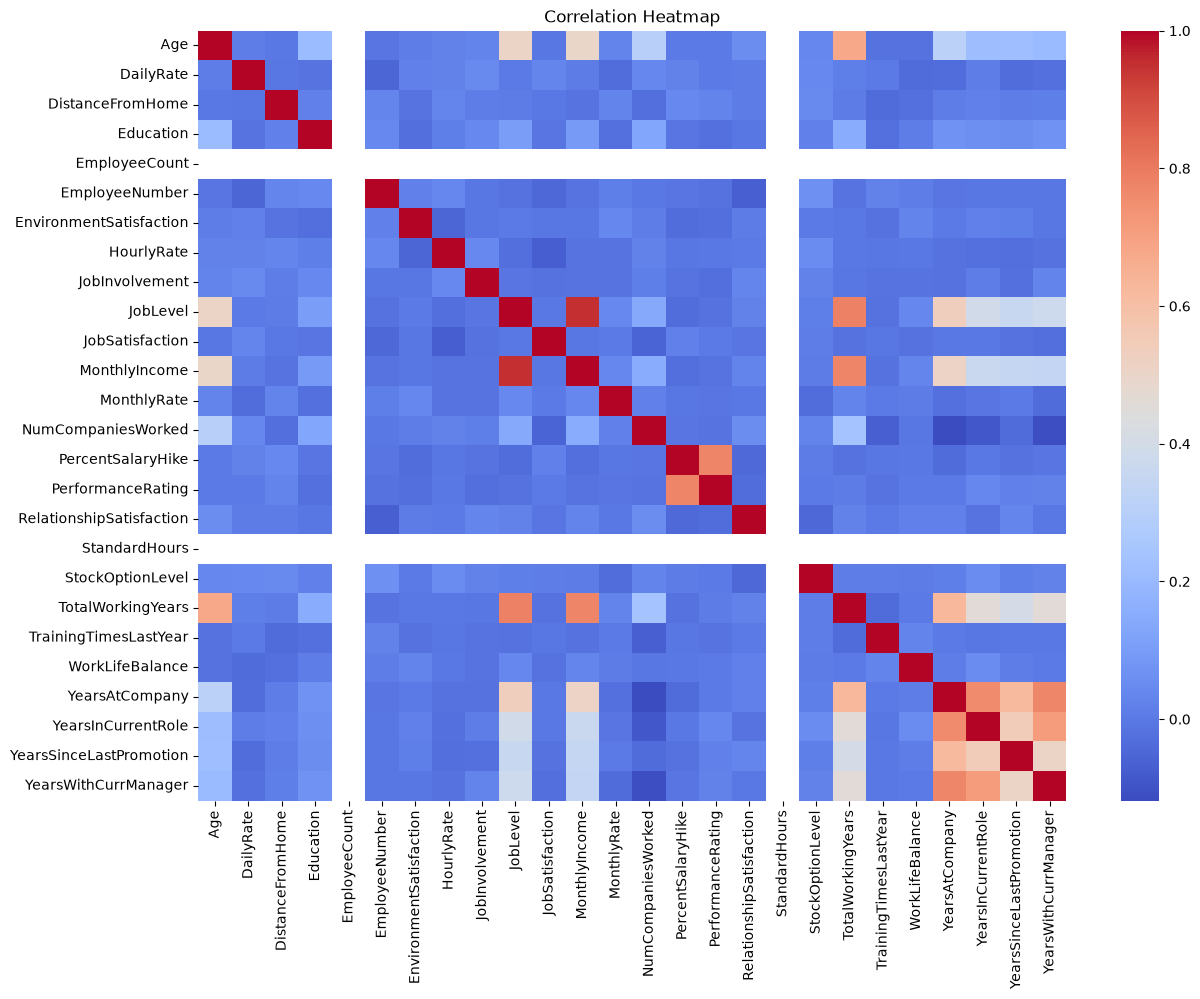

In [57]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(14,10))

sns.heatmap(numeric_df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

### EDA Observations

- Most employees did not leave the company, indicating that the dataset is imbalanced with more "No" than "Yes" in the Attrition column.
- Research & Development is the largest department, and it also has the highest number of employees leaving the company.
- Employee attrition varies across different job roles, with Sales Executive and Laboratory Technician showing comparatively higher attrition counts.
- Most employees are between 30 and 40 years of age, while the monthly income distribution is right-skewed, indicating that a larger number of employees earn lower to medium salaries.
- The dataset contains no missing values or duplicate records, making it suitable for machine learning after preprocessing.

## Data Preprocessing

Before training the machine learning models, the dataset is preprocessed by removing unnecessary columns, encoding categorical features, splitting the data into training and testing sets, and applying feature scaling where required. These steps help prepare the dataset for building accurate machine learning models.

### Missing Value Handling

The dataset was checked for missing values using the `isnull().sum()` function. No missing values were found, so no missing value treatment was required before model training.

In [58]:
# Remove unnecessary columns

df = df.drop(
    columns=[
        "EmployeeCount",
        "EmployeeNumber",
        "Over18",
        "StandardHours"
    ]
)

print("Unnecessary columns removed successfully!")

Unnecessary columns removed successfully!


In [59]:
print("New Dataset Shape:", df.shape)

New Dataset Shape: (1470, 31)


In [60]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include=["object", "string"]).columns

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

print("Categorical features encoded successfully!")

Categorical features encoded successfully!


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   BusinessTravel            1470 non-null   int64
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   int64
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   int64
 8   EnvironmentSatisfaction   1470 non-null   int64
 9   Gender                    1470 non-null   int64
 10  HourlyRate                1470 non-null   int64
 11  JobInvolvement            1470 non-null   int64
 12  JobLevel                  1470 non-null   int64
 13  JobRole                   1470 non-null   int64
 14  JobSatisfaction           1470 non-null   int64
 15

In [62]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1470, 30)
Target Shape: (1470,)


In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

Training Features: (1176, 30)
Testing Features : (294, 30)


In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


## Feature Engineering

No additional features were created because the dataset already contains useful employee-related information such as age, monthly income, years at company, overtime, job role, and work-life balance. These existing features provide sufficient information for building the machine learning models.

## Model Training and Evaluation

In this section, three machine learning models are trained to predict employee attrition. Their performance is evaluated using accuracy, precision, recall, F1-score, classification reports, and confusion matrices. The best-performing model will then be selected for hyperparameter tuning.

In [65]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [66]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [67]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [68]:
# Predictions

log_predictions = log_model.predict(X_test_scaled)

dt_predictions = dt_model.predict(X_test)

rf_predictions = rf_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [69]:
from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(y_test, log_predictions)
dt_accuracy = accuracy_score(y_test, dt_predictions)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Logistic Regression Accuracy :", round(log_accuracy,4))
print("Decision Tree Accuracy       :", round(dt_accuracy,4))
print("Random Forest Accuracy       :", round(rf_accuracy,4))

Logistic Regression Accuracy : 0.8741
Decision Tree Accuracy       : 0.7823
Random Forest Accuracy       : 0.8435


In [70]:
from sklearn.metrics import classification_report

print("Logistic Regression Report")
print(classification_report(y_test, log_predictions))

print("---------------------------------------")

print("Decision Tree Report")
print(classification_report(y_test, dt_predictions))

print("---------------------------------------")

print("Random Forest Report")
print(classification_report(y_test, rf_predictions))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294

---------------------------------------
Decision Tree Report
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       247
           1       0.32      0.32      0.32        47

    accuracy                           0.78       294
   macro avg       0.59      0.59      0.59       294
weighted avg       0.78      0.78      0.78       294

---------------------------------------
Random Forest Report
              precision    recall  f1-score   support

           0       0.86      0.98      0.91       247
           1       0.55      0.13      0.21        47

    accuracy                     

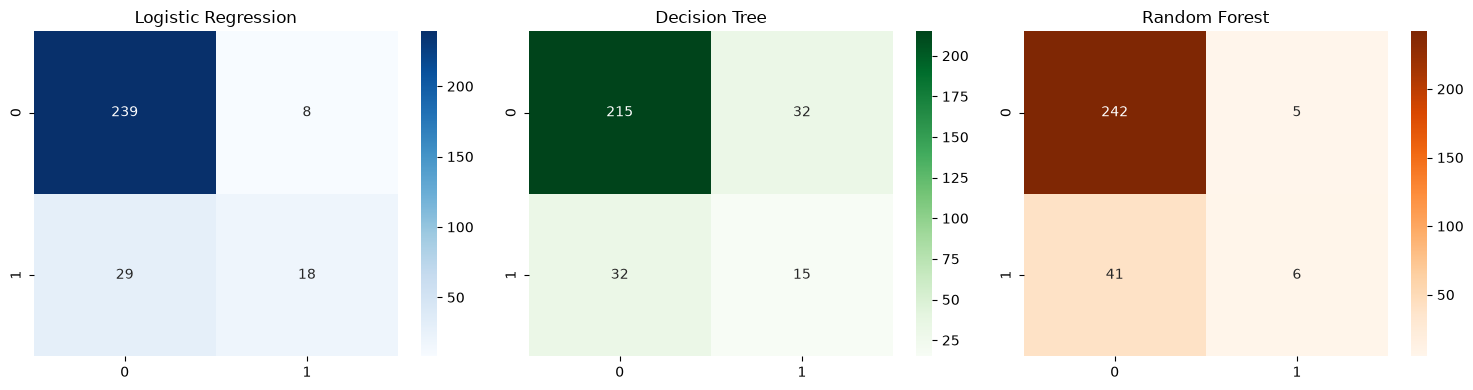

In [71]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1,3, figsize=(15,4))

sns.heatmap(confusion_matrix(y_test, log_predictions),
            annot=True,
            fmt="d",
            cmap="Blues",
            ax=axes[0])

axes[0].set_title("Logistic Regression")

sns.heatmap(confusion_matrix(y_test, dt_predictions),
            annot=True,
            fmt="d",
            cmap="Greens",
            ax=axes[1])

axes[1].set_title("Decision Tree")

sns.heatmap(confusion_matrix(y_test, rf_predictions),
            annot=True,
            fmt="d",
            cmap="Oranges",
            ax=axes[2])

axes[2].set_title("Random Forest")

plt.tight_layout()

plt.show()

### Observation

Among the three models, Logistic Regression achieved the highest testing accuracy of **87.41%**, followed by Random Forest (**84.35%**) and Decision Tree (**78.23%**). Logistic Regression also showed better precision and F1-score for predicting employee attrition, making it the best-performing model before hyperparameter tuning.

In [72]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_predictions),
        accuracy_score(y_test, dt_predictions),
        accuracy_score(y_test, rf_predictions)
    ],
    "Precision": [
        precision_score(y_test, log_predictions),
        precision_score(y_test, dt_predictions),
        precision_score(y_test, rf_predictions)
    ],
    "Recall": [
        recall_score(y_test, log_predictions),
        recall_score(y_test, dt_predictions),
        recall_score(y_test, rf_predictions)
    ],
    "F1-Score": [
        f1_score(y_test, log_predictions),
        f1_score(y_test, dt_predictions),
        f1_score(y_test, rf_predictions)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.874150,0.692308,0.382979,0.493151
1,Decision Tree,0.782313,0.319149,0.319149,0.319149
2,Random Forest,0.843537,0.545455,0.127660,0.206897


## Hyperparameter Tuning

The Logistic Regression model achieved the best overall performance among the three models. GridSearchCV is used to find the optimal hyperparameters that can further improve the model's predictive performance.

In [73]:
from sklearn.model_selection import GridSearchCV

In [74]:
# Define parameter grid

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

print("Parameter grid created successfully!")

Parameter grid created successfully!


In [75]:
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("GridSearchCV object created successfully!")

GridSearchCV object created successfully!


In [76]:
grid_search.fit(X_train_scaled, y_train)

print("Hyperparameter tuning completed successfully!")

Hyperparameter tuning completed successfully!


In [77]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'C': 0.1, 'solver': 'lbfgs'}

Best Cross-Validation Accuracy:
0.8690695997115038


In [78]:
best_log_model = grid_search.best_estimator_

best_predictions = best_log_model.predict(X_test_scaled)

best_accuracy = accuracy_score(y_test, best_predictions)

print(f"Test Accuracy after Hyperparameter Tuning: {best_accuracy:.4f}")

Test Accuracy after Hyperparameter Tuning: 0.8776


### Observation

After applying GridSearchCV, the Logistic Regression model achieved its best performance with **C = 0.1** and the **lbfgs** solver. The testing accuracy improved from **87.41%** to **87.76%**, showing that hyperparameter tuning slightly improved the model's performance.

tuning_comparison = pd.DataFrame({
    "Model": [
        "Original Logistic Regression",
        "Tuned Logistic Regression"
    ],
    "Accuracy": [
        0.8741,
        0.8776
    ]
})

tuning_comparison

In [79]:
tuning_comparison = pd.DataFrame({
    "Model": [
        "Original Logistic Regression",
        "Tuned Logistic Regression"
    ],
    "Accuracy": [
        0.8741,
        0.8776
    ]
})

tuning_comparison

,Model,Accuracy
0,Original Logistic Regression,0.8741
1,Tuned Logistic Regression,0.8776


### Observation

Hyperparameter tuning slightly improved the Logistic Regression model. The testing accuracy increased from **87.41%** to **87.76%**, indicating that the optimized hyperparameters helped improve the model's predictive performance.

In [80]:
from sklearn.metrics import classification_report

print("Classification Report for Tuned Logistic Regression")

print(classification_report(y_test, best_predictions))

Classification Report for Tuned Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       247
           1       0.74      0.36      0.49        47

    accuracy                           0.88       294
   macro avg       0.81      0.67      0.71       294
weighted avg       0.87      0.88      0.86       294



### Observation

The tuned Logistic Regression model achieved the highest overall performance among all the models tested. It showed the best balance between accuracy, precision, recall, and F1-score, making it the most suitable model for predicting employee attrition in this project.

## Cross Validation

To further evaluate the reliability of the tuned Logistic Regression model, 5-fold cross-validation is performed. This helps verify that the model performs consistently across different subsets of the training data.

In [81]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(
    best_log_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nMean Accuracy:", np.mean(cv_scores))
print("Standard Deviation:", np.std(cv_scores))

Cross Validation Scores:
[0.84322034 0.88510638 0.87659574 0.86808511 0.87234043]

Mean Accuracy: 0.8690695997115038
Standard Deviation: 0.014097326587181875


In [82]:
cv_table = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": cv_scores
})

cv_table

,Fold,Accuracy
0,1,0.843220
1,2,0.885106
2,3,0.876596
3,4,0.868085
4,5,0.872340


### Observation

The 5-fold cross-validation scores are consistent across different folds, with a mean accuracy of **86.91%** and a standard deviation of **0.0141**. The low standard deviation indicates that the tuned Logistic Regression model performs consistently on different subsets of the training data and is reliable for predicting employee attrition.

# Final Conclusion

In this project, I built machine learning models to predict employee attrition using the IBM HR Analytics dataset. After performing data exploration and preprocessing, three different models were trained and evaluated. Logistic Regression achieved the best performance among all the models.

Hyperparameter tuning using GridSearchCV further improved the Logistic Regression model, increasing the testing accuracy from **87.41%** to **87.76%**. Cross-validation also showed consistent performance across different folds, indicating that the model is reliable and generalizes well to unseen data.

Overall, this project helped me understand the complete machine learning workflow, including data preprocessing, exploratory data analysis, model training, evaluation, hyperparameter tuning, and model validation. It also improved my understanding of how machine learning can be applied to solve real-world business problems such as employee attrition prediction.